DeepSet, 4 * num_dim, 100 observation,DeepSet, num_dim,epochs=256, inference network: depth=8, widths=(256,256,256), "norm": "layer"

In [1]:
import pickle
from pathlib import Path

import bayesflow as bf
import keras
import numpy as np
import pandas as pd

from benchmark.examples.gaussian.datasets.datasets import GetDatasets
from benchmark.examples.gaussian.datasets.calculation import Calculation
from benchmark.examples.gaussian.analysis import summry_diagnostic as sd

sd.quiet_bayesflow_progress()

INFO:jax._src.xla_bridge:Unable to initialize backend 'rocm': module 'jaxlib.xla_extension' has no attribute 'GpuAllocatorConfig'
INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: dlopen(libtpu.so, 0x0001): tried: 'libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibtpu.so' (no such file), '/opt/anaconda3/envs/benchmark2/bin/../lib/libtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache), 'libtpu.so' (no such file), '/usr/local/lib/libtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache)
INFO:bayesflow:Using backend 'jax'


In [2]:
RNG = np.random.default_rng(2025)
num_dims = 20
num_obs = 100
num_datasets = 50
num_samples = 1000
n_ref = 2000

project_dir = Path("/Users/yimingzang/Documents/thesis/benchmark2/benchmark/examples/gaussian")
network_dir = project_dir / "networks"
result_dir = project_dir / "results" / "ood"
dataset_dir = result_dir / "datasets"
figure_dir = result_dir / "figures"

source_specs = {
    "m1": {"mu_prior_mean": 0.0, "mu_prior_std": 1.0, "likelihood_std": 1.0},
    "m2": {"mu_prior_mean": 3.0, "mu_prior_std": 1.0, "likelihood_std": 1.0},
    "m3": {"mu_prior_mean": 0.0, "mu_prior_std": 1.0, "likelihood_std": 3.0},
    "m4": {"mu_prior_mean": 0.1, "mu_prior_std": 1.0, "likelihood_std": 1.0},

    "m5": {"mu_prior_mean": 1.5, "mu_prior_std": 1.0, "likelihood_std": 1.0},
    "m6": {"mu_prior_mean": 5.0, "mu_prior_std": 1.0, "likelihood_std": 1.0},
    "m7": {"mu_prior_mean": 0.0, "mu_prior_std": 1.0, "likelihood_std": 5.0},
    "m8": {"mu_prior_mean": 0.0, "mu_prior_std": 3.0, "likelihood_std": 1.0},
    
    "m9": {"mu_prior_mean": 0.0, "mu_prior_std": 1.0, "likelihood_std": 0.1},
    "m10": {"mu_prior_mean": 0.0, "mu_prior_std": 1.0, "likelihood_std": 0.01},

    "m11": {"mu_prior_mean": 0.0, "mu_prior_std": 0.1, "likelihood_std": 1},
    "m12": {"mu_prior_mean": 0.0, "mu_prior_std": 0.01, "likelihood_std": 1},
}
assumed_specs = {key: source_specs[key] for key in sd.ASSUMED_MODELS}
#pd.DataFrame(source_specs).T

In [3]:
def save_pickle(obj, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("wb") as file:
        pickle.dump(obj, file)


def load_pickle(path):
    with Path(path).open("rb") as file:
        return pickle.load(file)

In [ ]:
datasets = {source: load_pickle(dataset_dir / f"{source}_raw.pkl") for source in sd.SOURCE_MODELS}

In [4]:
# Load trained approximators
filepath_m1 = network_dir / "m1_s_20d_100n.keras"
filepath_m2 = network_dir / "m2_s_20d_100n.keras"
filepath_m3 = network_dir / "m3_s_20d_100n.keras"
filepath_m4 = network_dir / "m4_s_20d_100n.keras"
filepath_direct = network_dir / "direct_s_20d_100n.keras"

approximator_m1 = keras.saving.load_model(filepath_m1)
approximator_m2 = keras.saving.load_model(filepath_m2)
approximator_m3 = keras.saving.load_model(filepath_m3)
approximator_m4 = keras.saving.load_model(filepath_m4)

approximator_direct = keras.saving.load_model(filepath_direct)

approximators = {"m1": approximator_m1, "m2": approximator_m2, "m3": approximator_m3, "m4": approximator_m4}

In [5]:
# Fit summary-space reference distributions
def make_simulator(spec, seed):
    rng = np.random.default_rng(seed)

    def prior():
        mu = rng.normal(loc=spec["mu_prior_mean"], scale=spec["mu_prior_std"], size=num_dims)
        return {"mu": mu}

    def likelihood(mu):
        x = rng.normal(loc=mu, scale=spec["likelihood_std"], size=(num_obs, num_dims))
        return {"x": x}

    return bf.make_simulator([prior, likelihood])


simulators = {
    assumed: make_simulator(assumed_specs[assumed], 3025 + i)
    for i, assumed in enumerate(sd.ASSUMED_MODELS) 
}
distance_metric = "linf"
references = sd.fit_summary_references(approximators, simulators, n_ref=n_ref, distance_metric=distance_metric)
pd.DataFrame({k: {"metric": v["distance_metric"], "summary_dim": v["summary_dim"], "dm_low": v["dm_low"], "dm_high": v["dm_high"], "median": v["median"]} for k, v in references.items()}).T

,metric,summary_dim,dm_low,dm_high,median
m1,linf,80,0.504279,0.996451,0.702533
m2,linf,80,0.504945,1.008632,0.701265
m3,linf,80,0.486965,1.033531,0.690887
m4,linf,80,0.49862,1.003306,0.696525


In [6]:
# Add dynamic distance regimes and x(y) score
datasets = {source: load_pickle(dataset_dir / f"{source}_processed.pkl") for source in sd.SOURCE_MODELS}
datasets = sd.add_distances_and_regimes(datasets, approximators, references)

logml_df = sd.collect_logml_distance_frame(datasets)
pmp_df = sd.collect_pmp_ambiguity_frame(datasets)
logml_summary, pmp_summary = sd.summarize_frames(logml_df, pmp_df)

result_dir.mkdir(parents=True, exist_ok=True)
logml_df.to_csv(result_dir / "logml_distance_frame.csv", index=False)
pmp_df.to_csv(result_dir / "pmp_ambiguity_frame.csv", index=False)
logml_summary.to_csv(result_dir / "logml_summary.csv", index=False)
pmp_summary.to_csv(result_dir / "pmp_summary.csv", index=False)
for source, data in datasets.items():
    save_pickle(data, dataset_dir / f"{source}_processed.pkl")

In [7]:
display(logml_summary[logml_summary["source_model"]=="m9"].round(3))
# display(pmp_summary.round(3))

,assumed_model,source_model,distance_regime,n,median_d_M,median_signed_logml_error
49,m1,m9,in_distribution,26,0.875,-14.544
50,m2,m9,extrapolation,50,1.439,-175.252
51,m3,m9,extrapolation,50,1.699,-36.105
52,m4,m9,in_distribution,30,0.908,-0.084
53,m1,m9,extrapolation,24,1.108,-10.934
54,m4,m9,extrapolation,20,1.091,-0.195


In [ ]:
# load datasets for plotting
datasets = {source: load_pickle(dataset_dir / f"{source}_processed.pkl") for source in sd.SOURCE_MODELS}
logml_df = pd.read_csv(result_dir / "logml_distance_frame.csv")
pmp_df = pd.read_csv(result_dir / "pmp_ambiguity_frame.csv")

## Plots

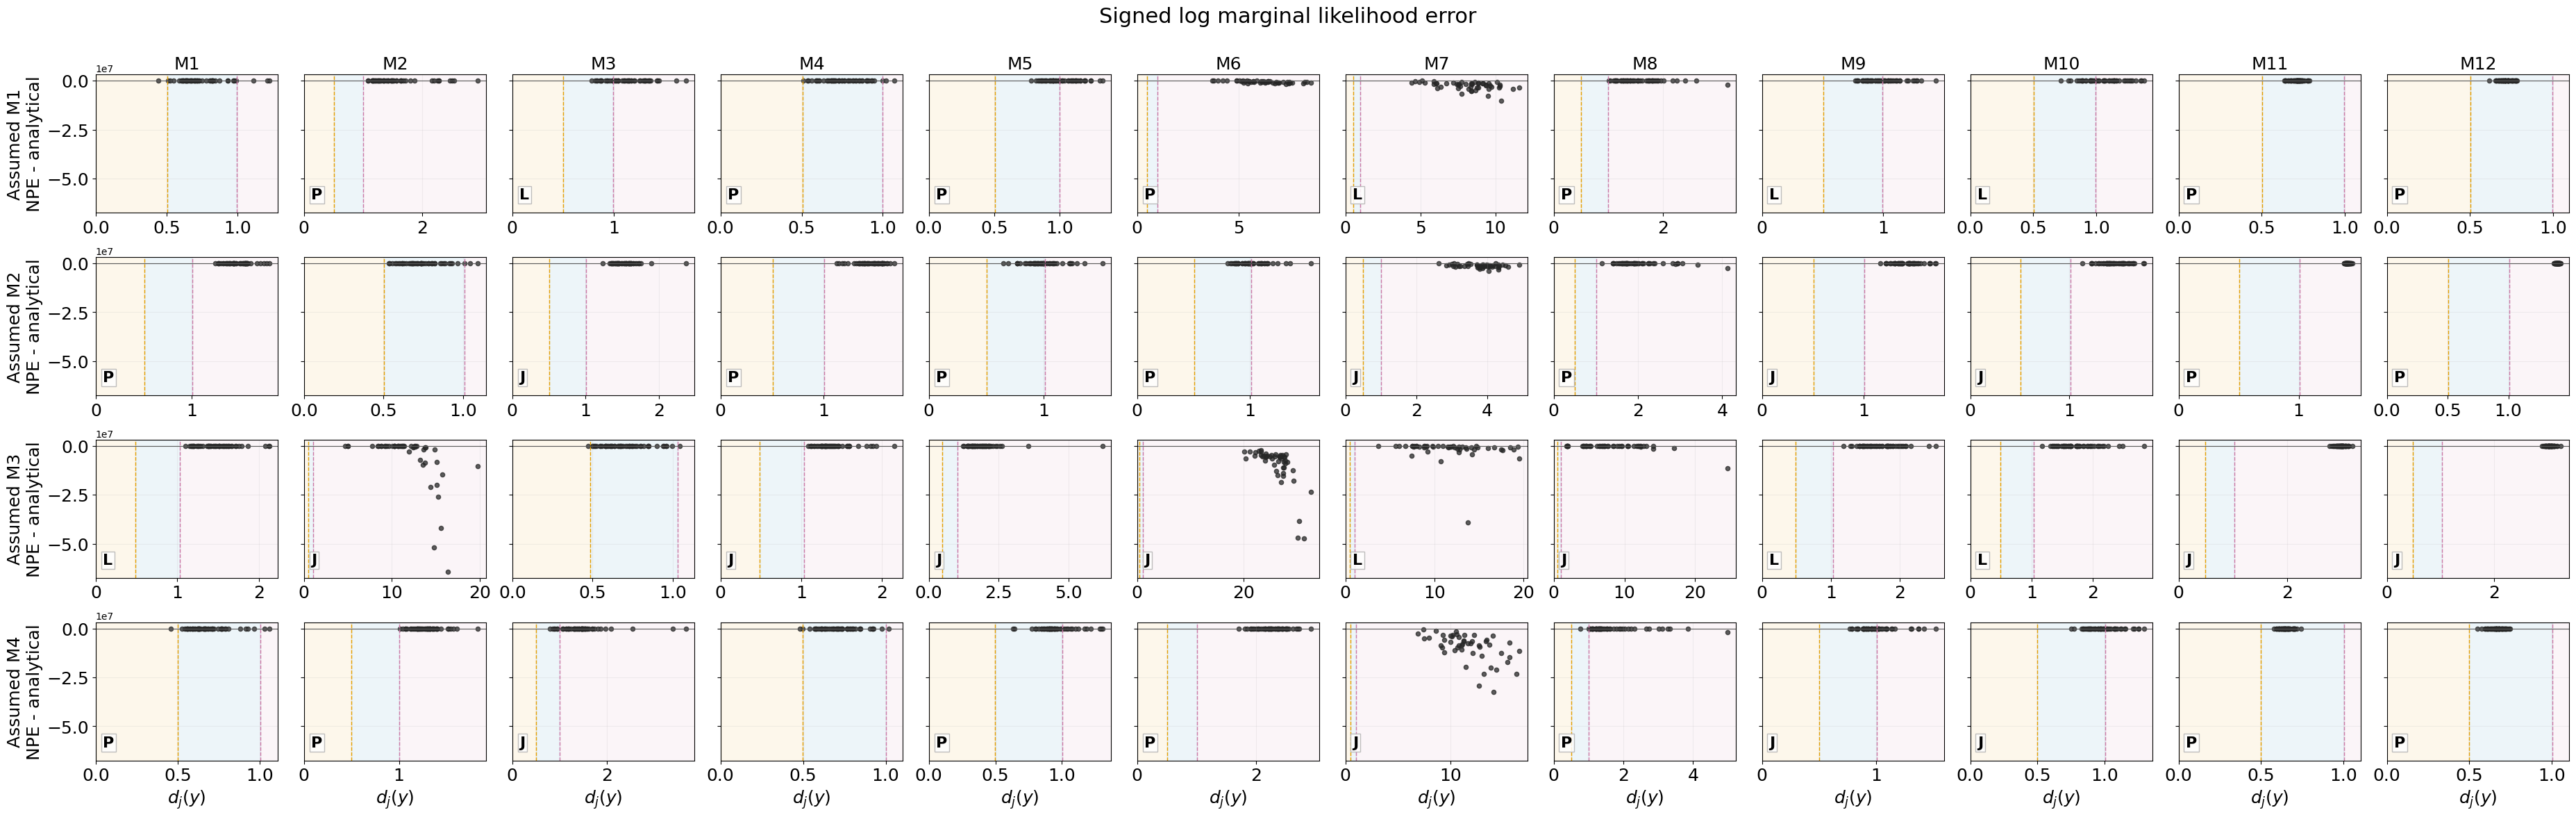

In [9]:
# signed logml error with shared y-axis
sd.plot_signed_logml_error_grid(logml_df, output_dir=figure_dir);
# sd.plot_logml_error_vs_distance(logml_df, color_by="source", output_dir=figure_dir,error_bound=1000);
# sd.plot_logml_error_vs_distance(logml_df, color_by="gold_logml", output_dir=figure_dir);

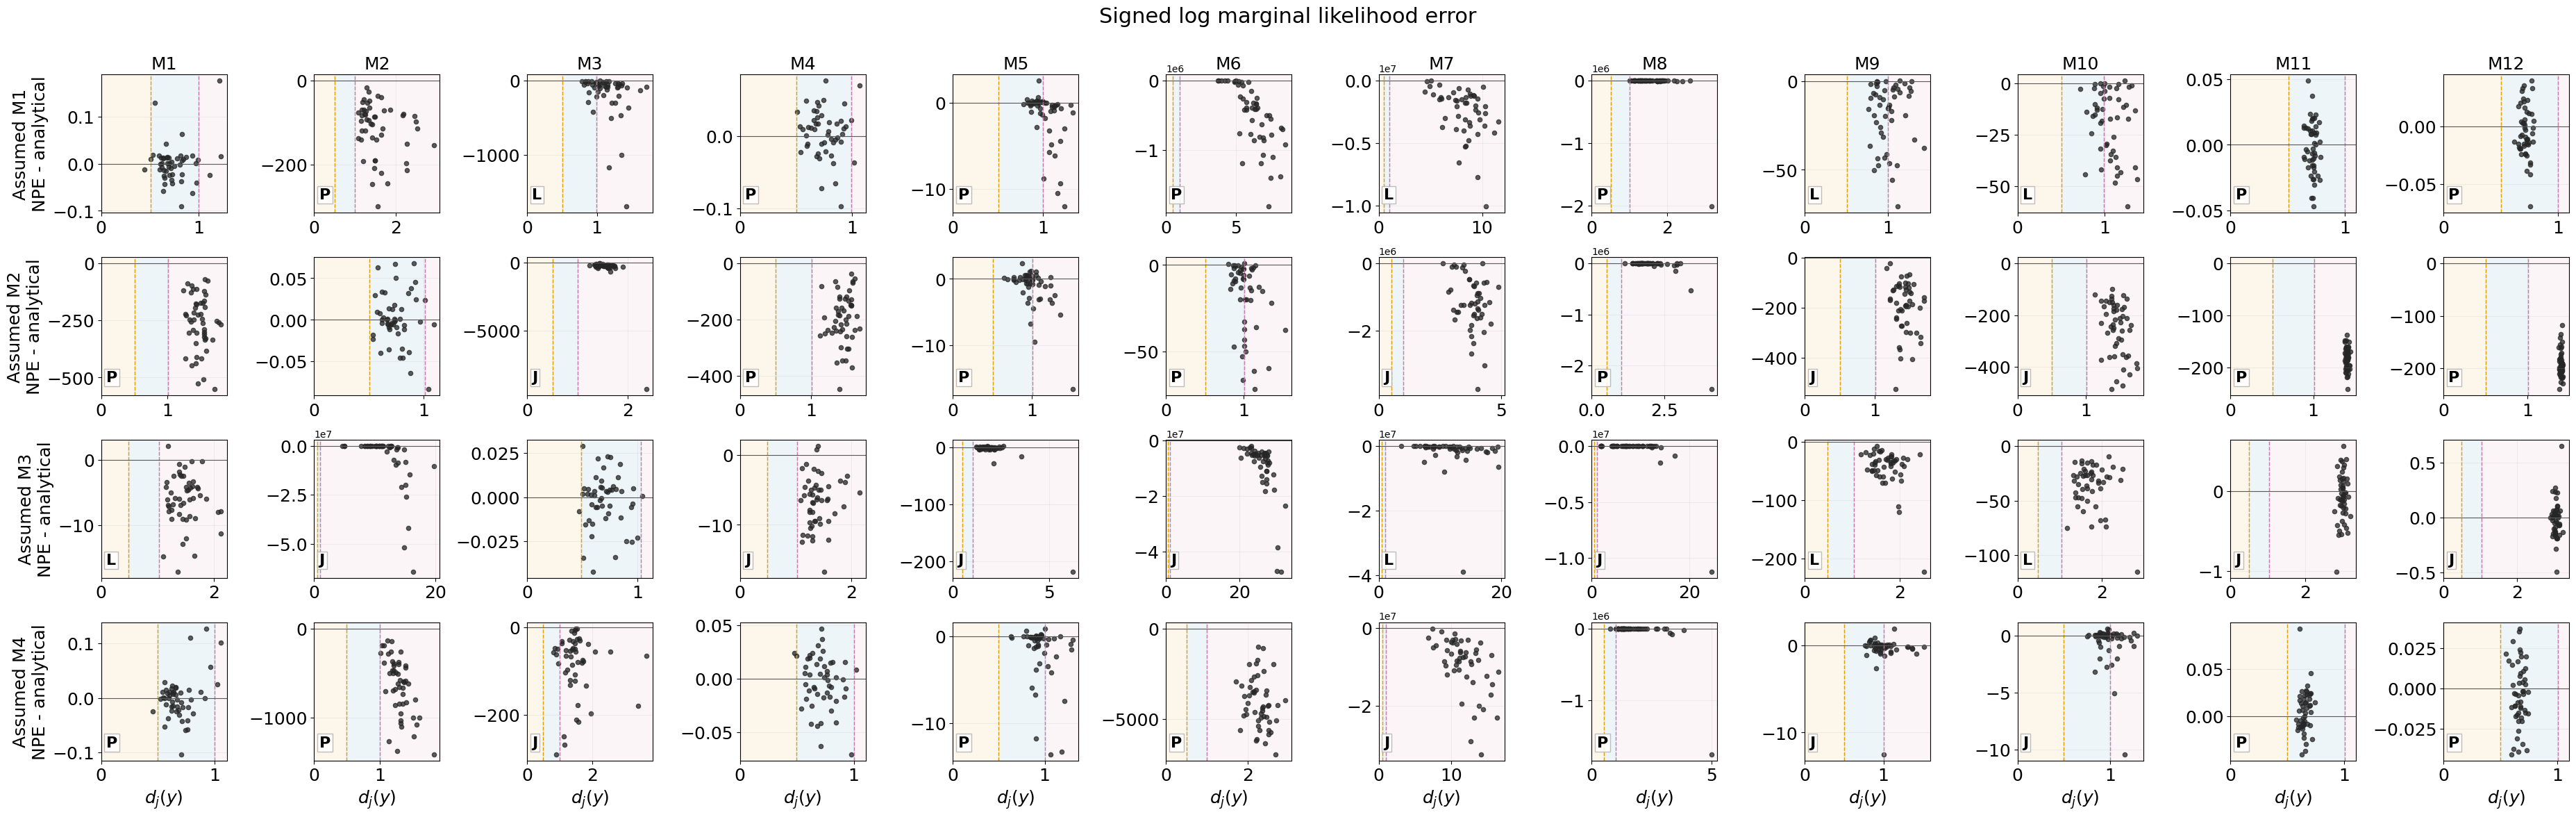

In [10]:
sd.plot_signed_logml_error_grid(logml_df, output_dir=figure_dir,sharey=False);

(<Figure size 1960x600 with 4 Axes>,
 array([<Axes: title={'center': 'M1 PMP'}, xlabel='$A_{\\mathrm{true}}(y)$', ylabel='$\\hat{p}(M_j|y)-p(M_j|y)$'>,
        <Axes: title={'center': 'M2 PMP'}, xlabel='$A_{\\mathrm{true}}(y)$'>,
        <Axes: title={'center': 'M3 PMP'}, xlabel='$A_{\\mathrm{true}}(y)$'>,
        <Axes: title={'center': 'M4 PMP'}, xlabel='$A_{\\mathrm{true}}(y)$'>],
       dtype=object))

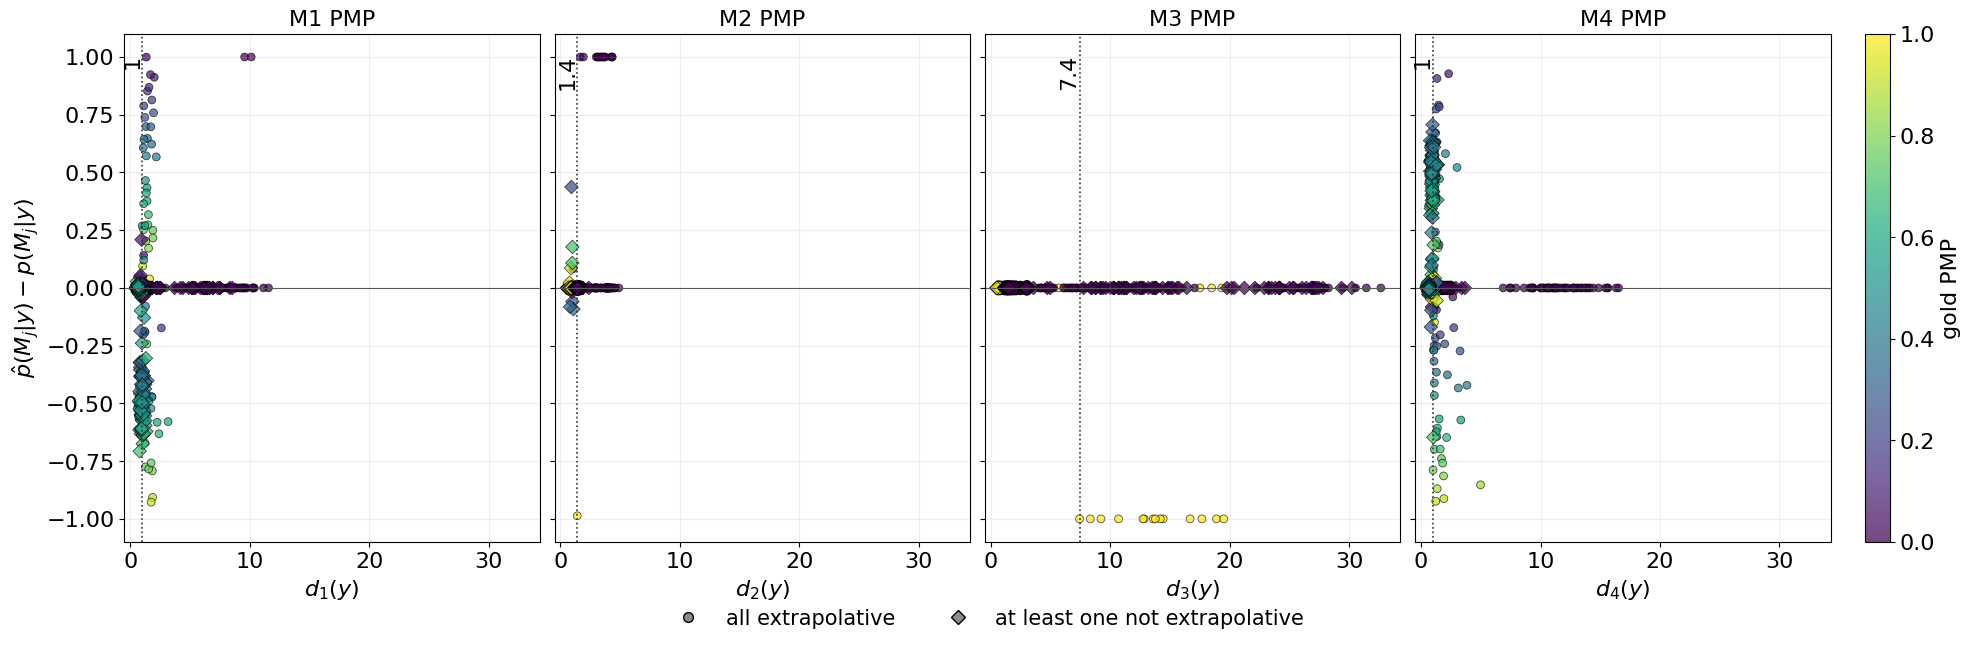

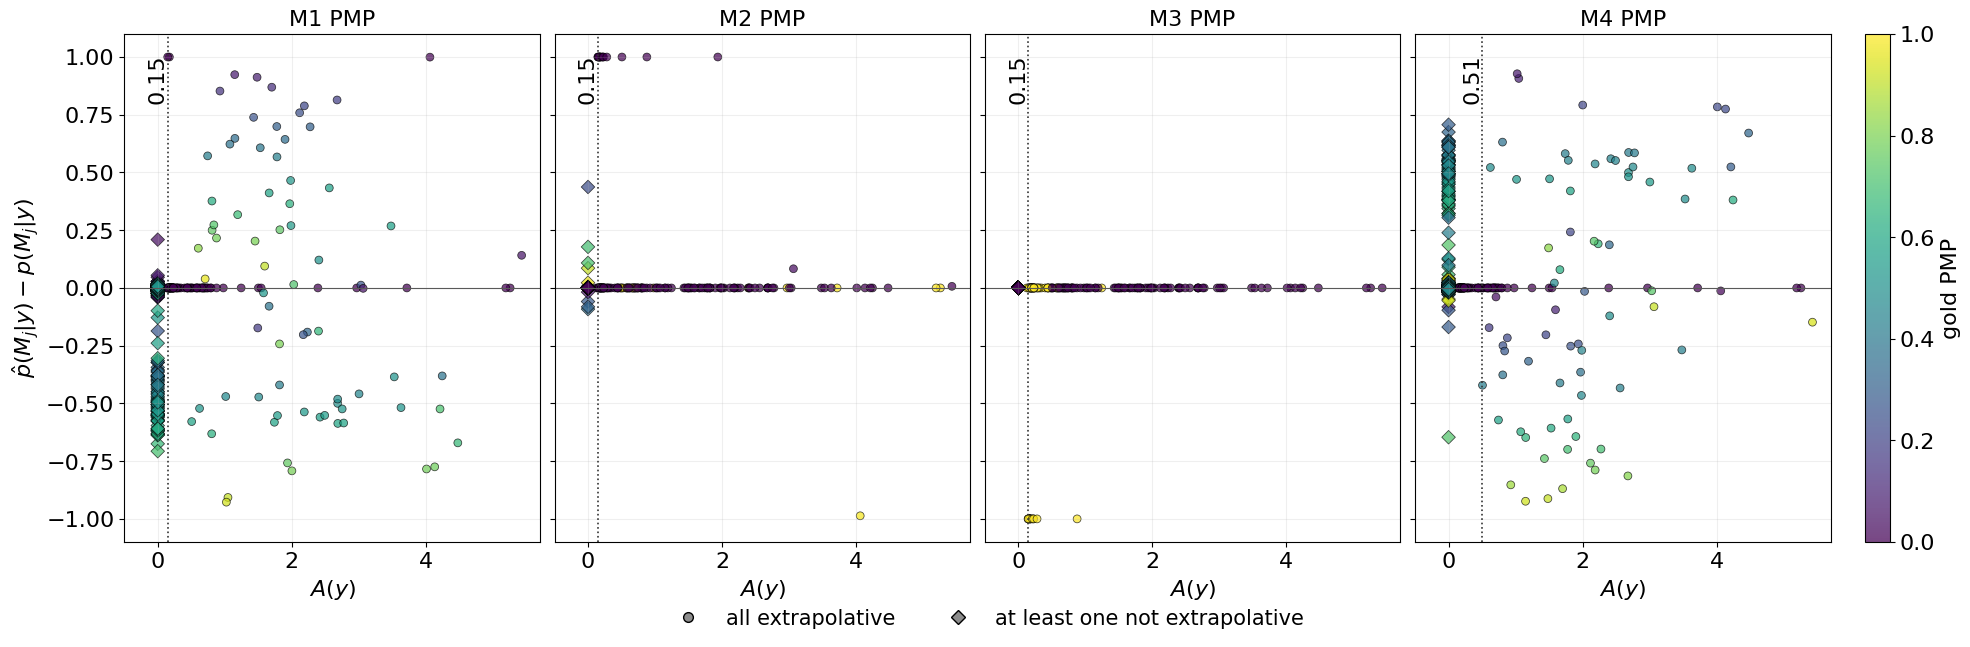

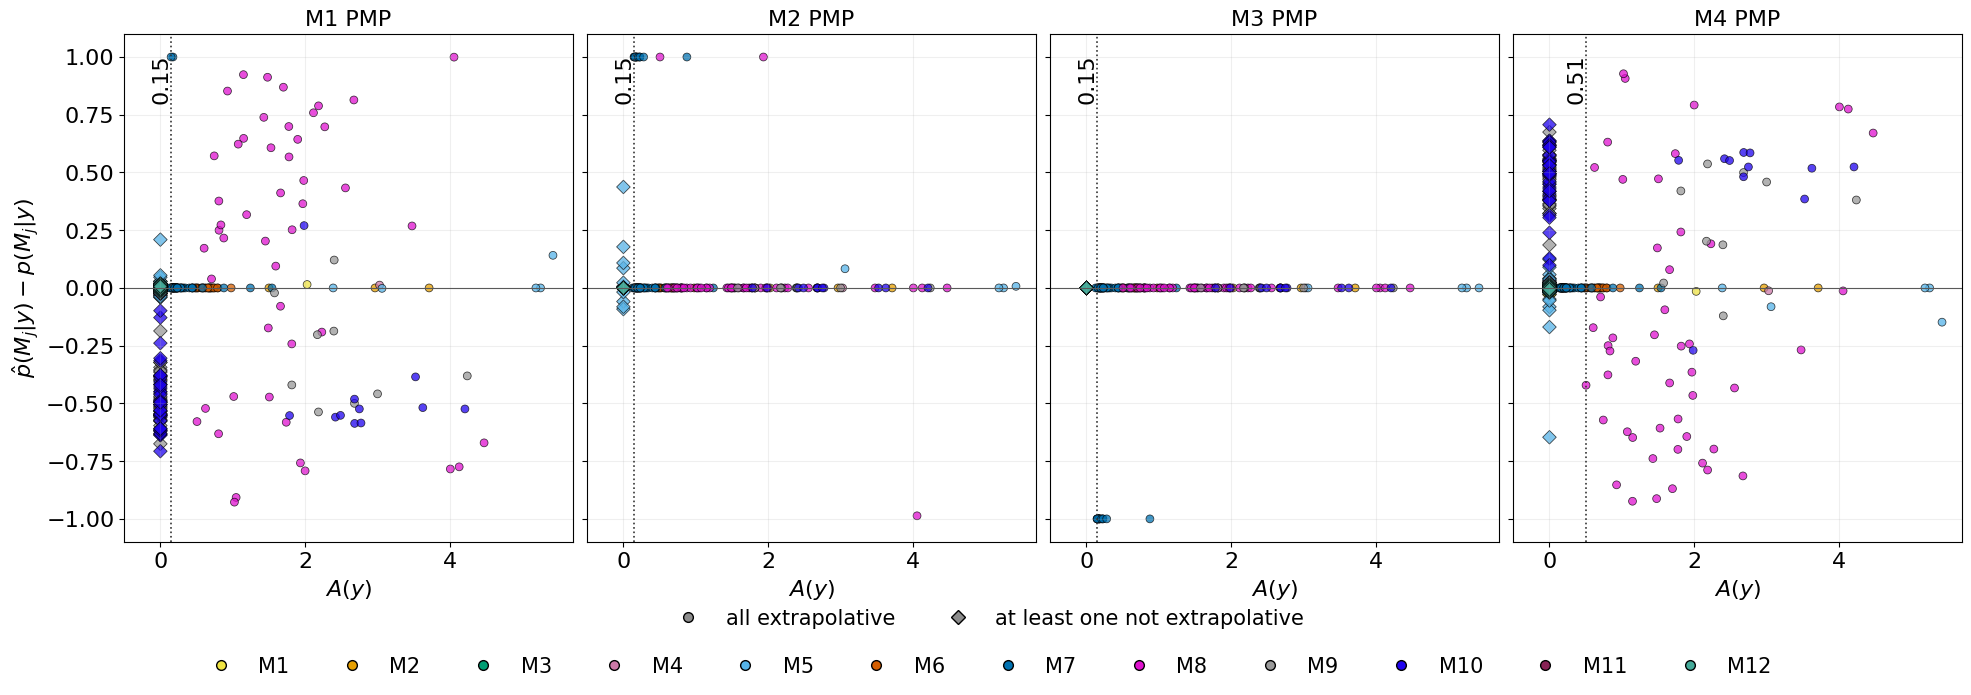

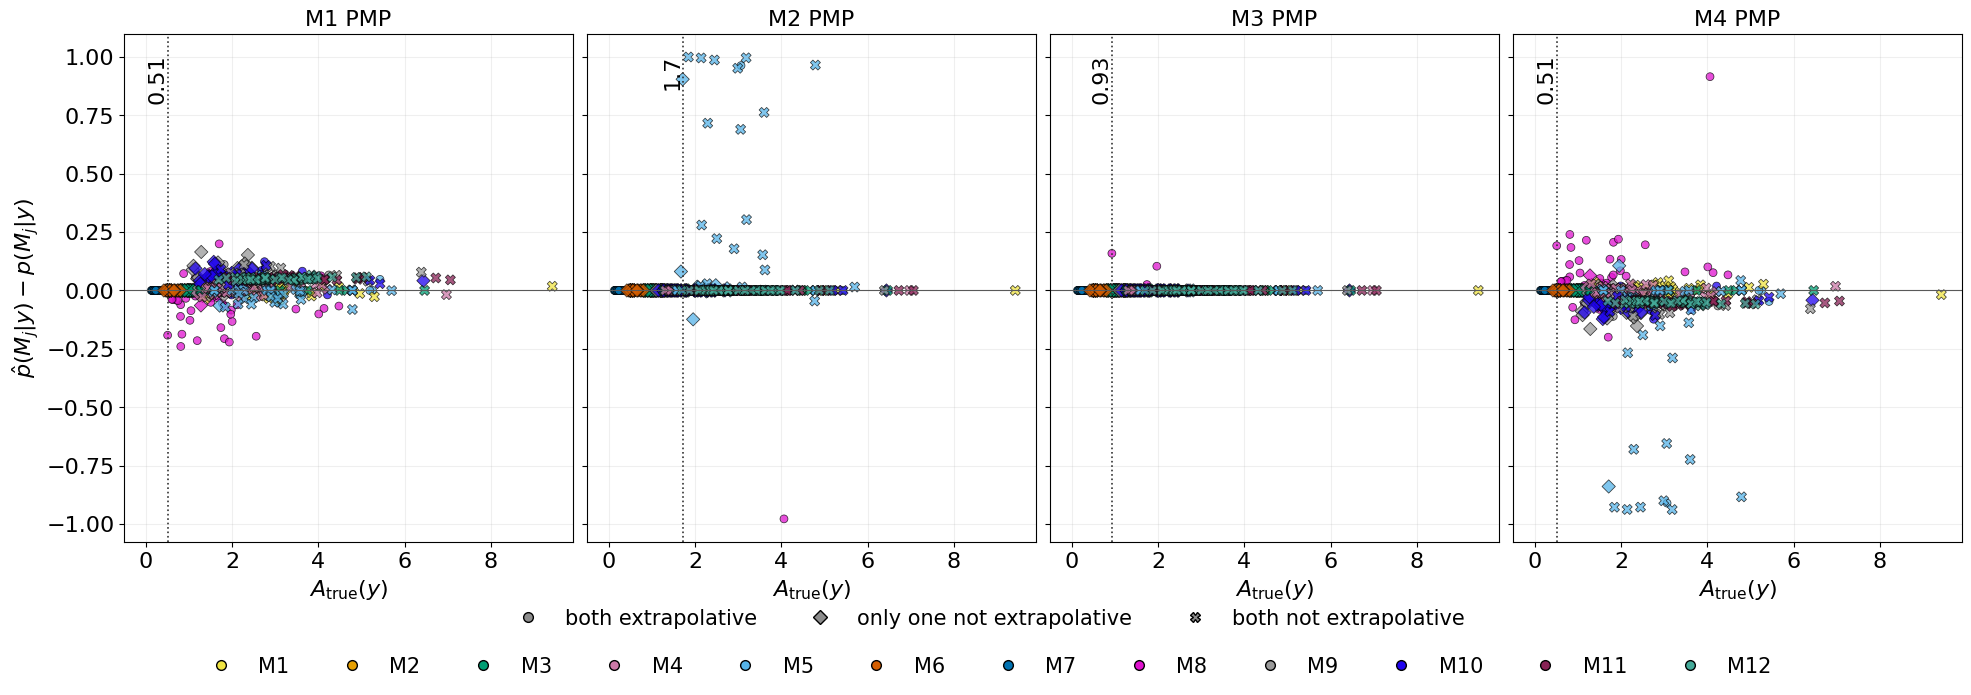

In [20]:
# PMP plots
sd.plot_pmp_diagnostic(pmp_df, x="distance", y="signed_error", group_by="global_extrapolation", estimate="npe", output_dir=figure_dir, filename="x_vs_pmp_error_npe.png", sharex=True, error_bound=0.1,error_subset="all_extrapolative")

sd.plot_pmp_diagnostic(pmp_df, x="logA", y="signed_error", group_by="global_extrapolation", estimate="npe", output_dir=figure_dir, filename="x_vs_pmp_error_npe.png", sharex=True, error_bound=0.1,error_subset="all_extrapolative")
sd.plot_pmp_diagnostic(pmp_df,x="logA",y="signed_error",group_by="global_extrapolation_source",estimate="npe",output_dir=figure_dir,filename="pmp_error_global_extrapolation_by_source.png",sharex=True,error_bound=0.1,error_subset="all_extrapolative")

# PMP plots with true A without setting A=0 for non-extrapolative points
# sd.plot_pmp_diagnostic(pmp_df,x="logA_true",y="signed_error",group_by="global_extrapolation_source",estimate="npe",output_dir=figure_dir,filename="pmp_error_global_extrapolation_by_source.png",sharex=True,error_bound=0.1,)
# sd.plot_pmp_diagnostic(pmp_df,x="logA_true",y="signed_error",group_by="nearest_two_source",estimate="npe",output_dir=figure_dir,filename="pmp_error_global_extrapolation_by_source.png",sharex=True,error_bound=0.1,)

sd.plot_pmp_diagnostic(pmp_df,x="logA_true",y="signed_error",group_by="nearest_two_source",estimate="direct",output_dir=figure_dir,filename="pmp_error_global_extrapolation_by_source.png",sharex=True,error_bound=0.1,)

(<Figure size 1960x600 with 5 Axes>,
 array([<Axes: title={'center': 'M1 PMP'}, xlabel='$A(y)$', ylabel='$\\hat{p}(M_j|y)-p(M_j|y)$'>,
        <Axes: title={'center': 'M2 PMP'}, xlabel='$A(y)$'>,
        <Axes: title={'center': 'M3 PMP'}, xlabel='$A(y)$'>,
        <Axes: title={'center': 'M4 PMP'}, xlabel='$A(y)$'>], dtype=object))

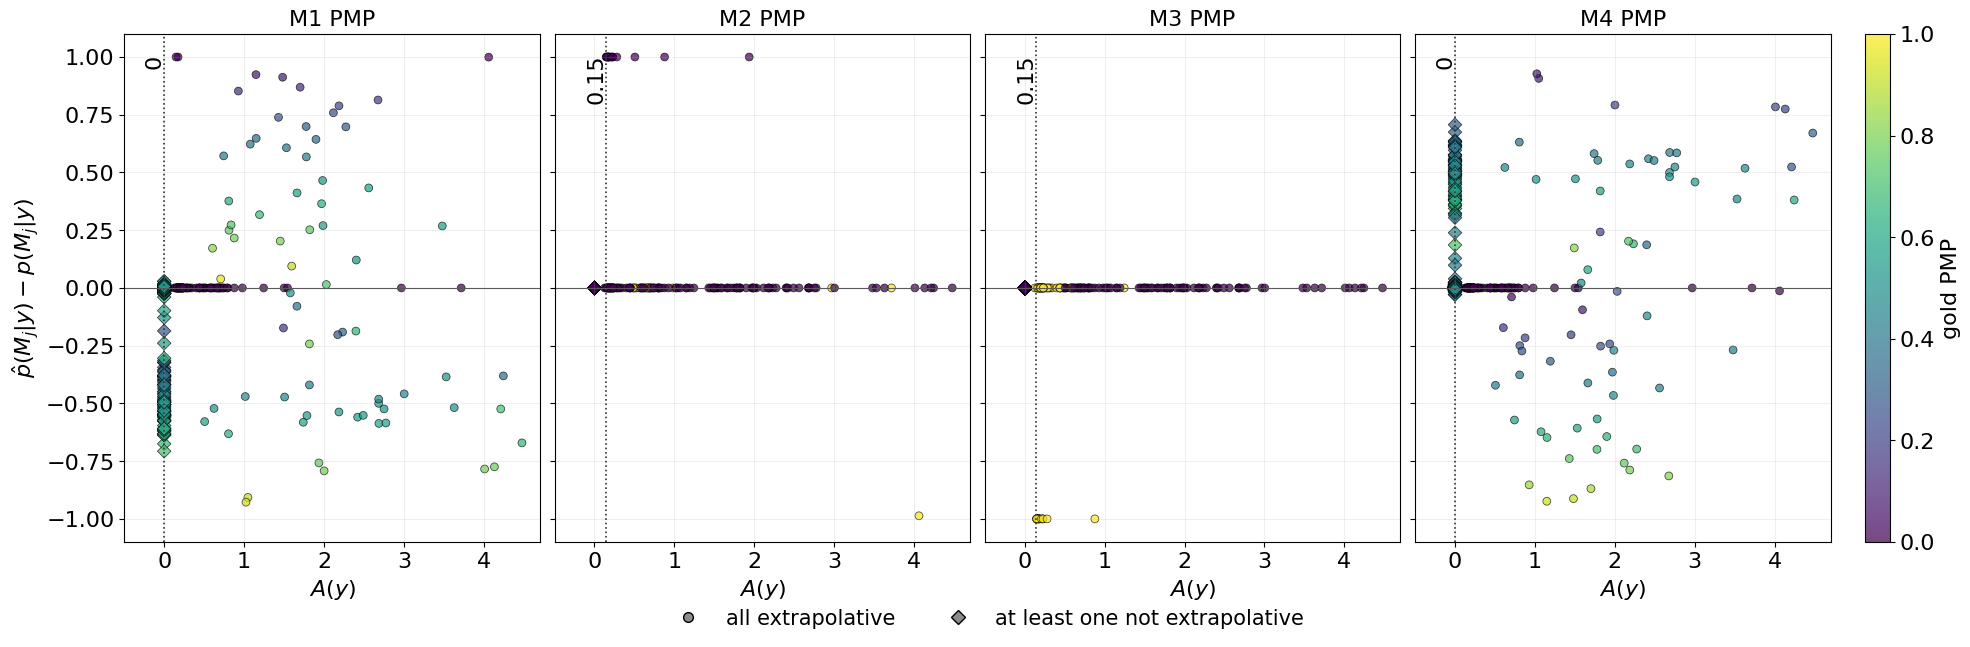

In [12]:
# PMP plots excluding m5 and m4
pmp_no_m5 = pmp_df[pmp_df["source_model"] != "m5"].copy()
pmp_no_m5 = pmp_no_m5[pmp_no_m5["source_model"] != "m4"].copy()

sd.plot_pmp_diagnostic(pmp_no_m5,x="logA",y="signed_error",group_by="global_extrapolation",estimate="npe",output_dir=figure_dir,filename="x_vs_pmp_error_no_m5_npe.png",sharex=True,error_bound=0.1,)

In [18]:
# # PMP estimates (NPE and NPMP) vs distance for each source model
# for source in sd.SOURCE_MODELS:
#     sd.plot_pmp_estimates_vs_distance(pmp_df, source,output_dir=figure_dir)

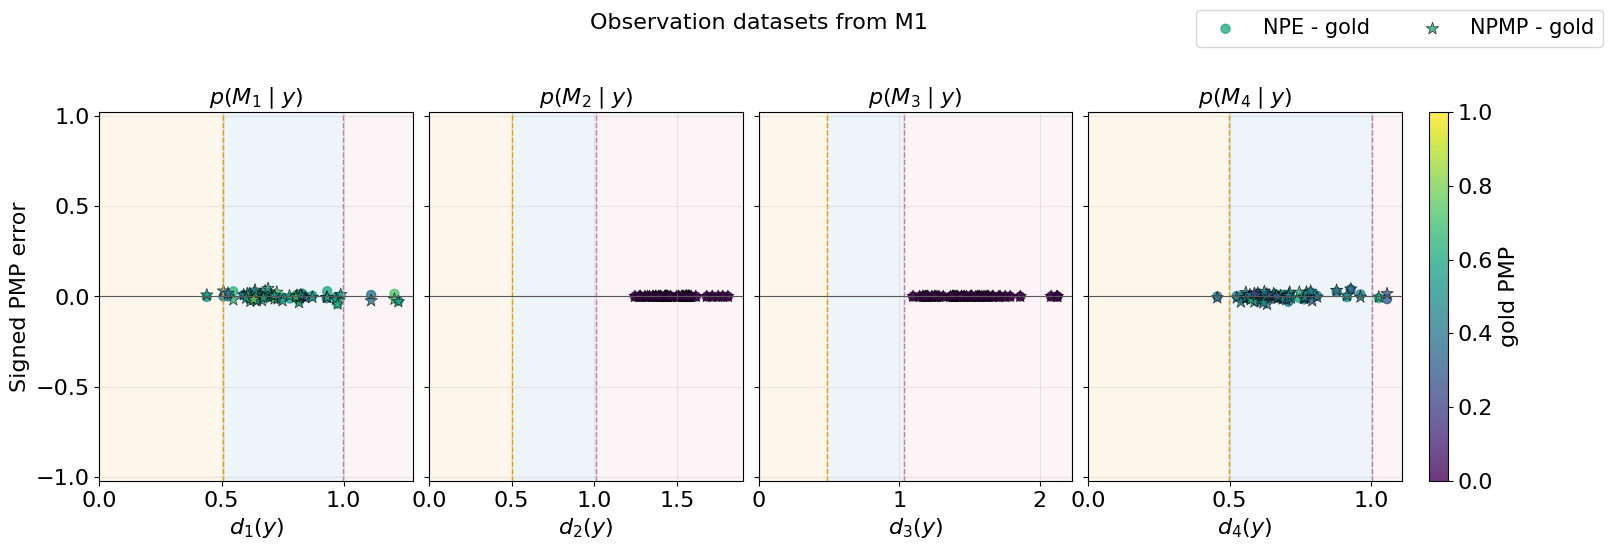

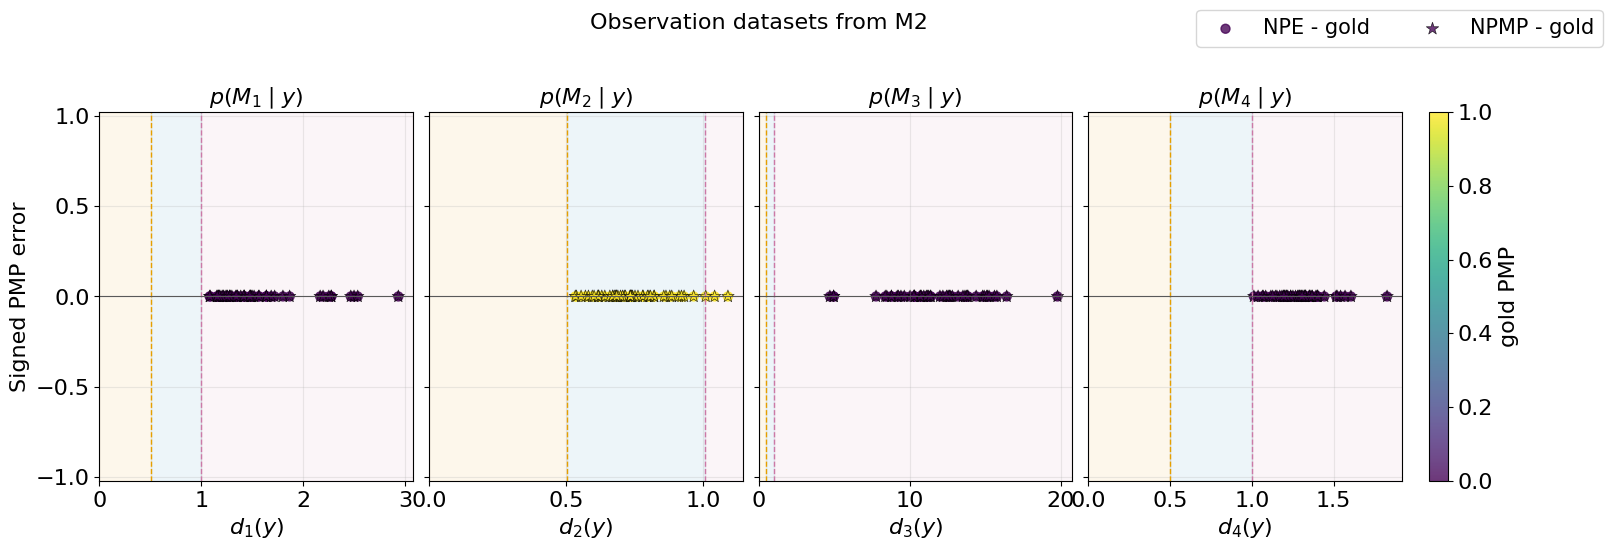

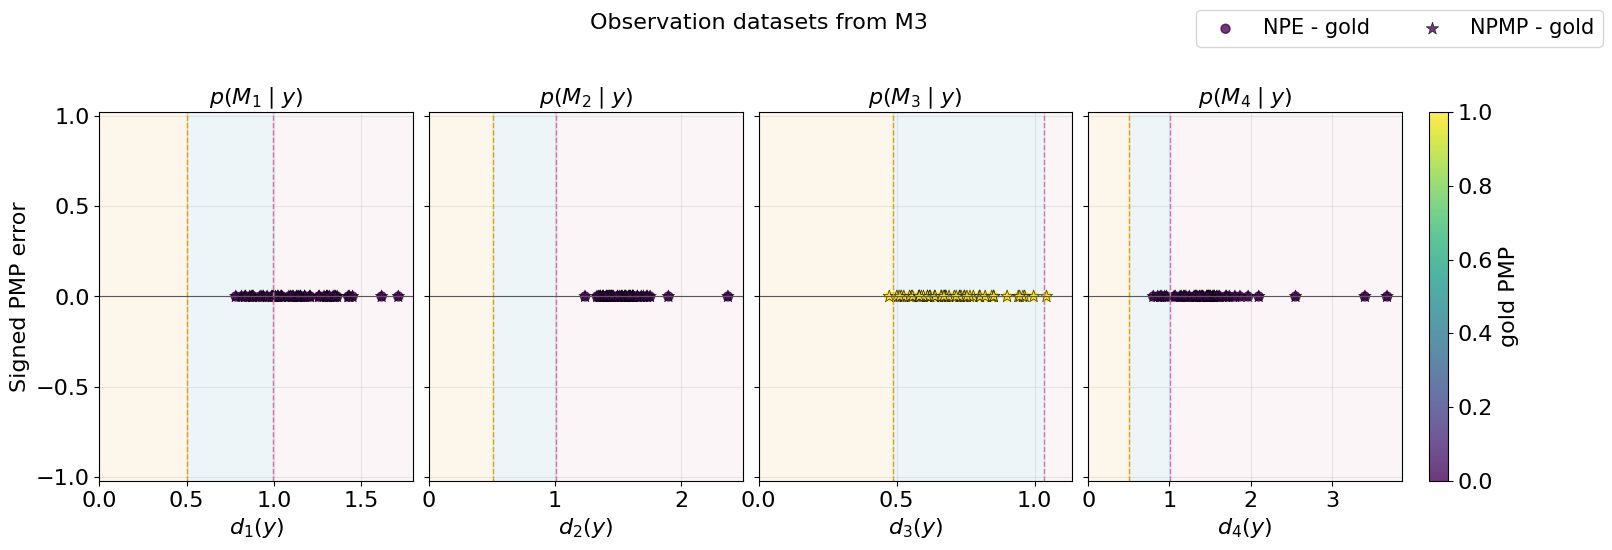

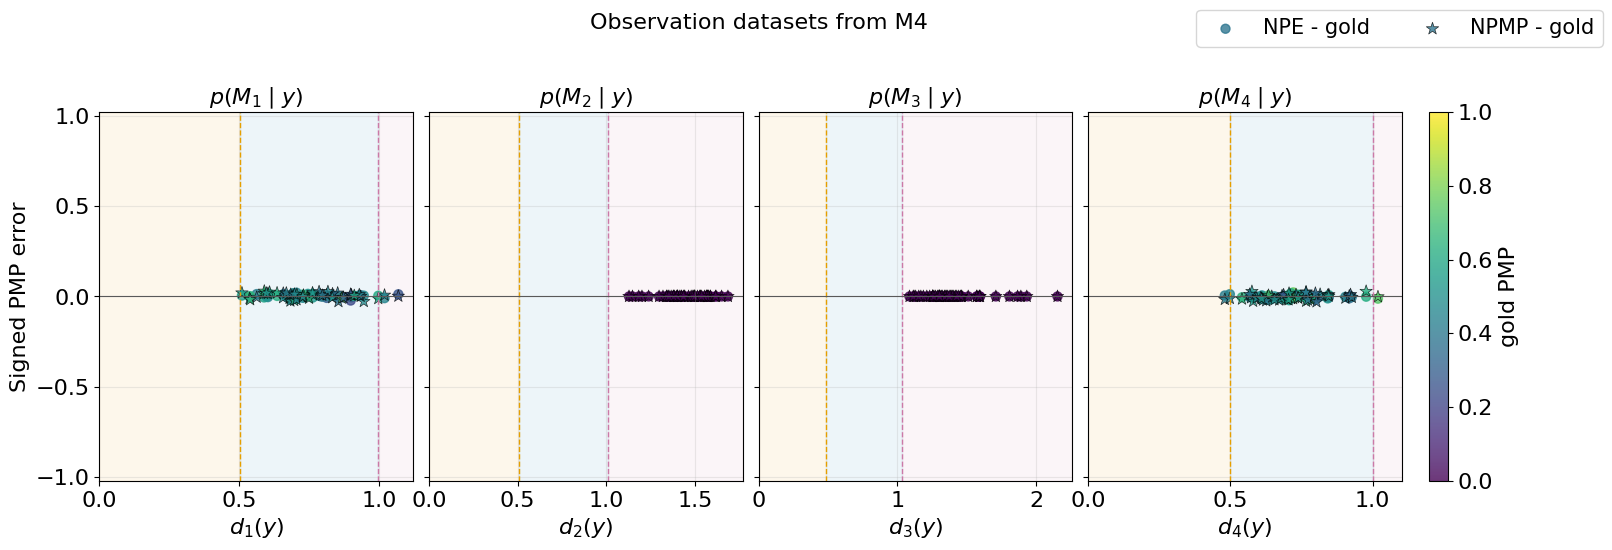

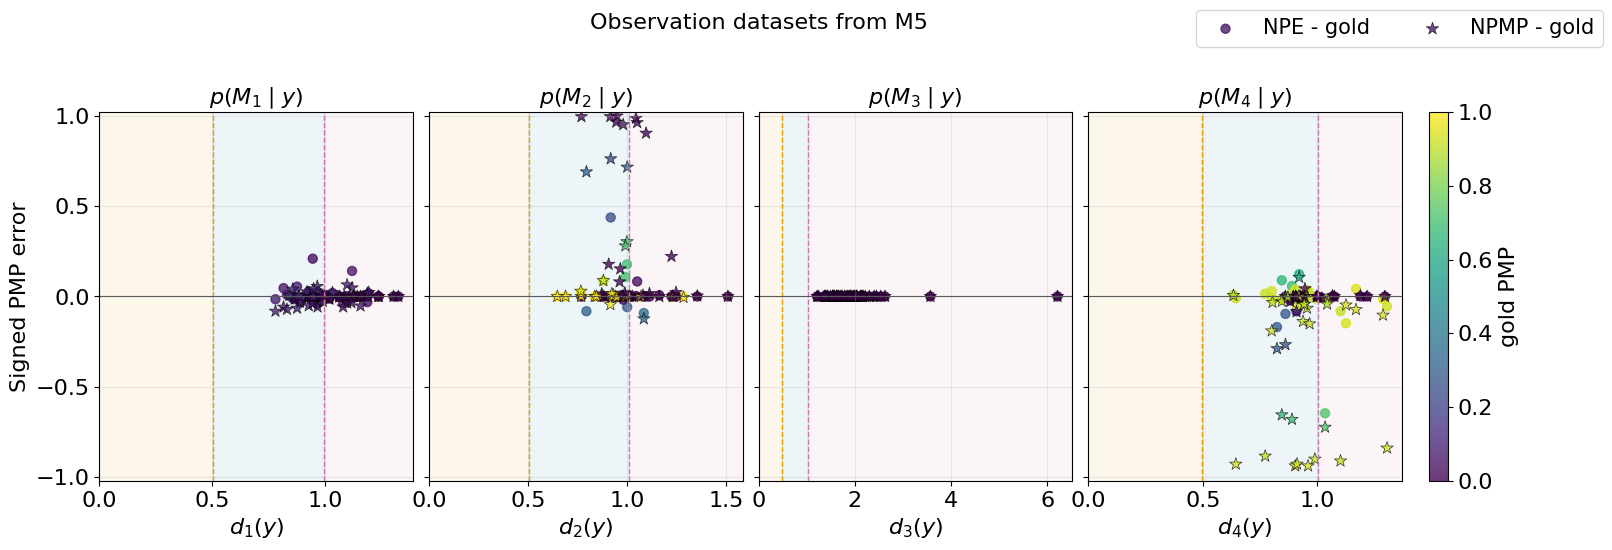

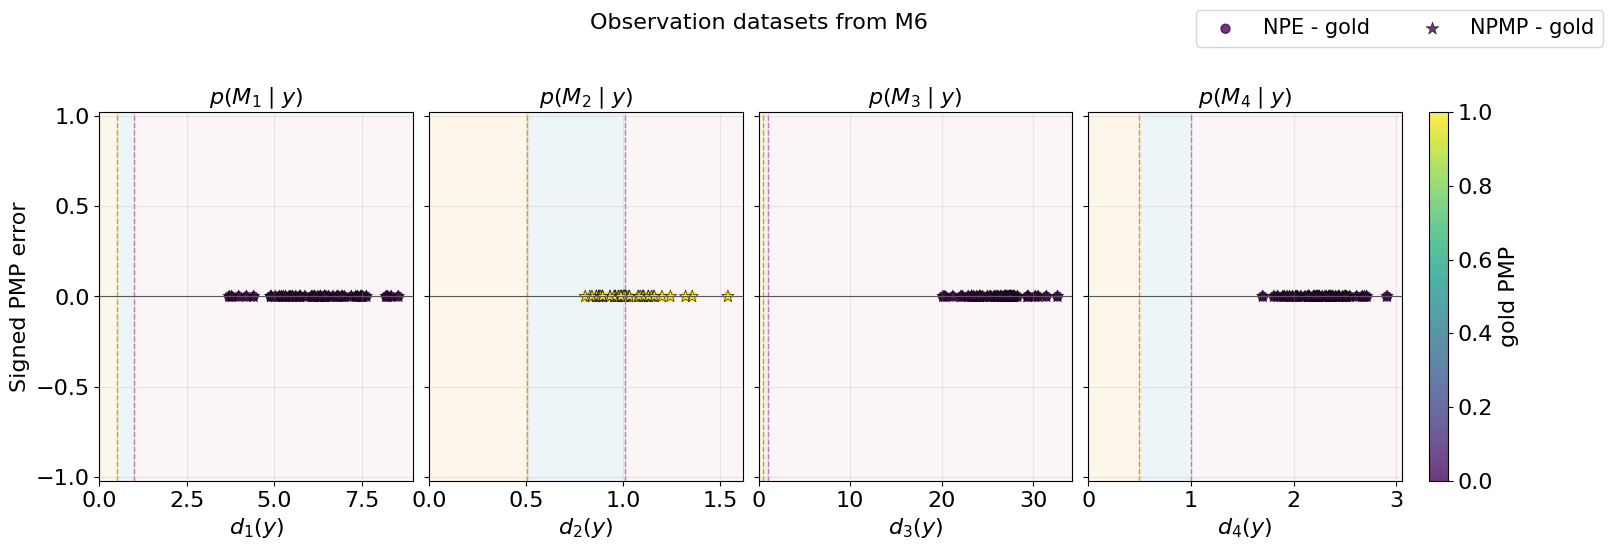

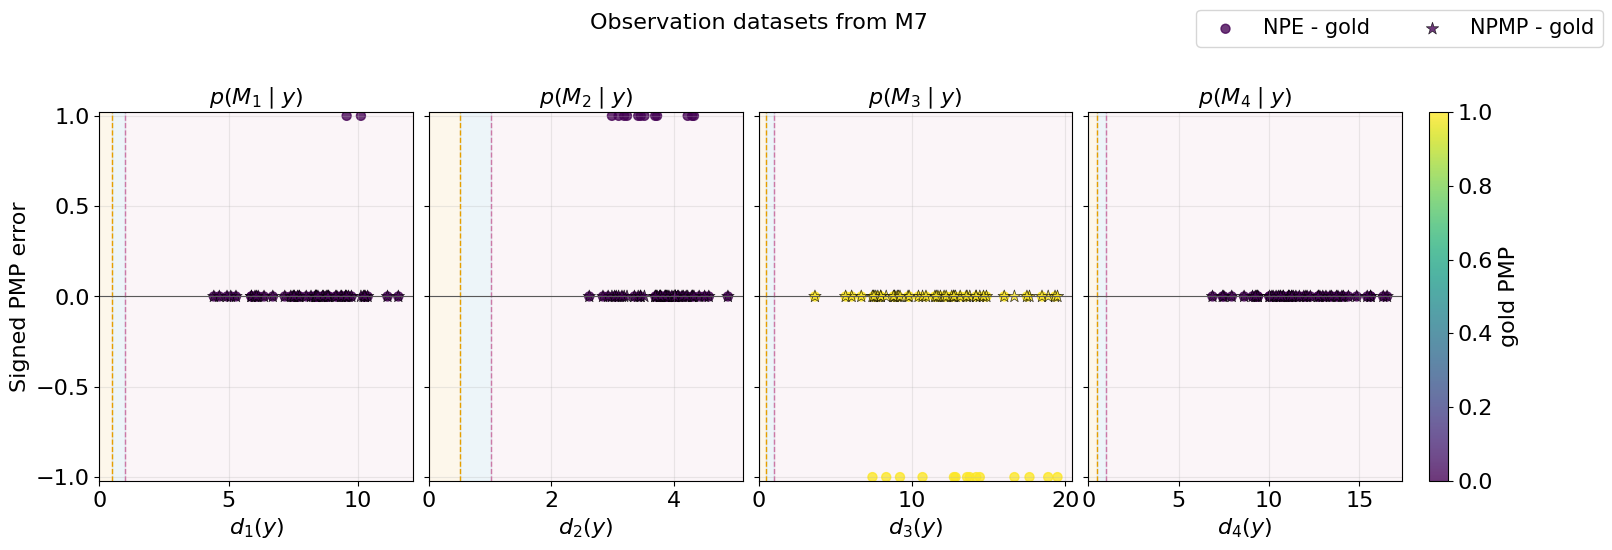

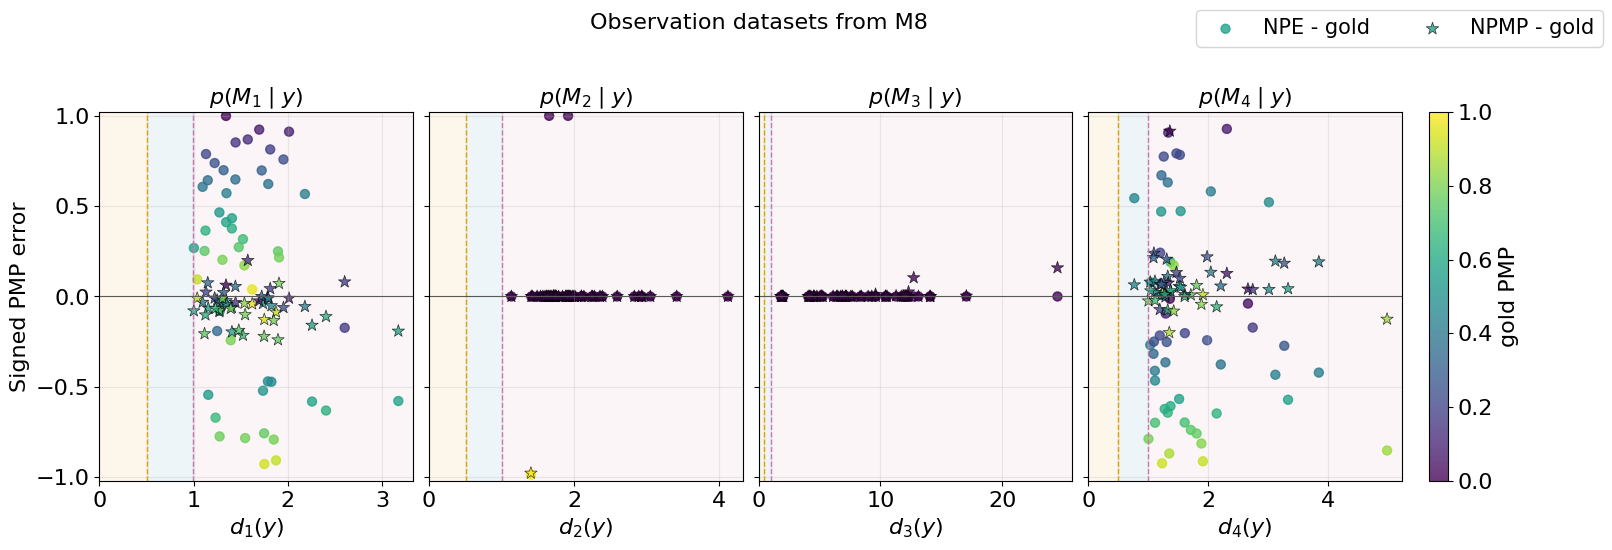

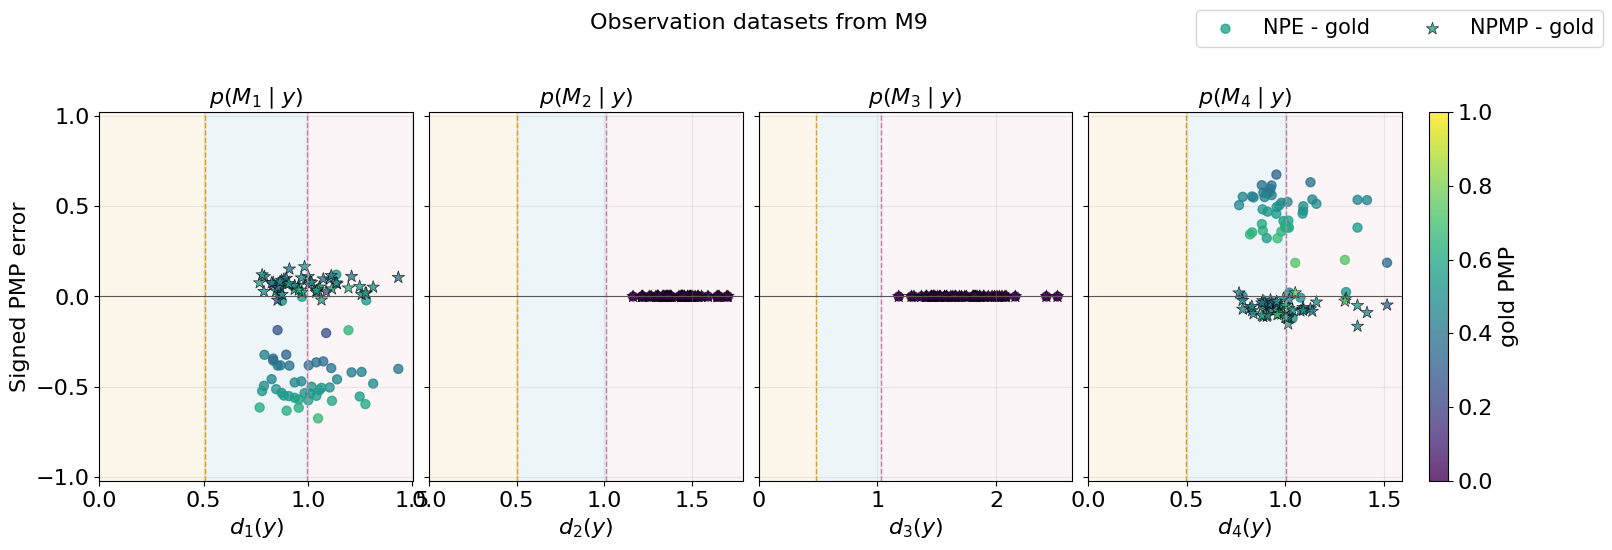

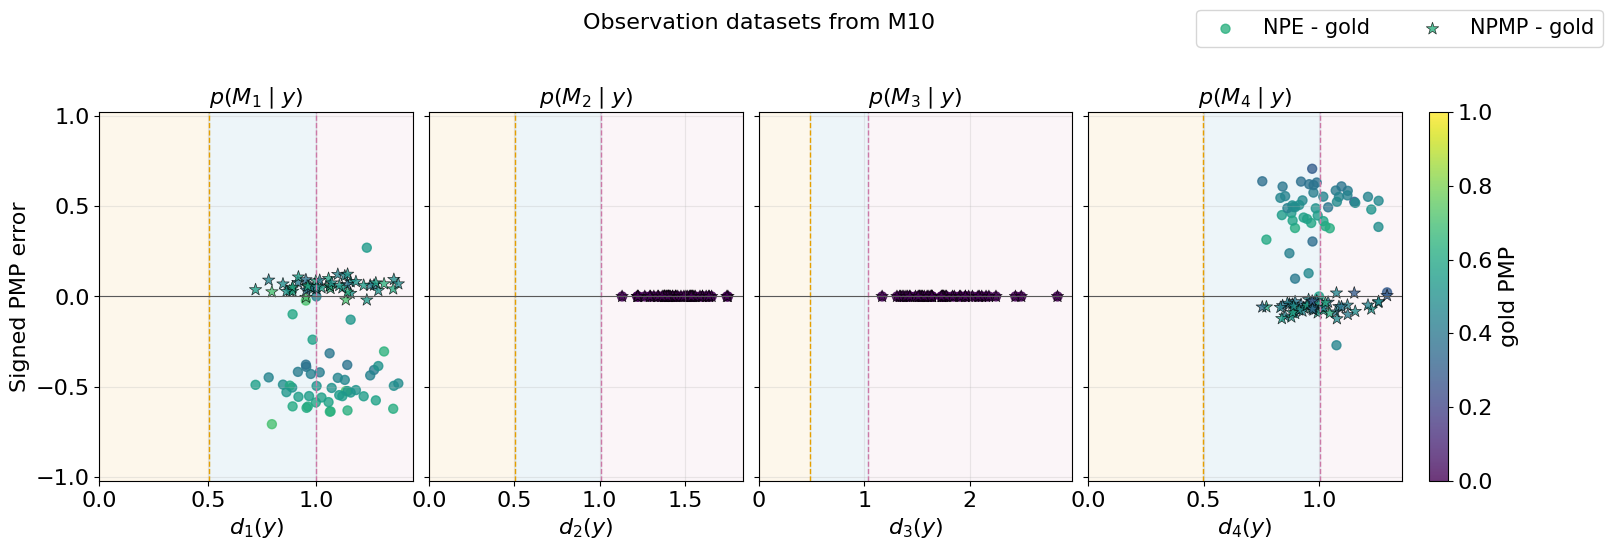

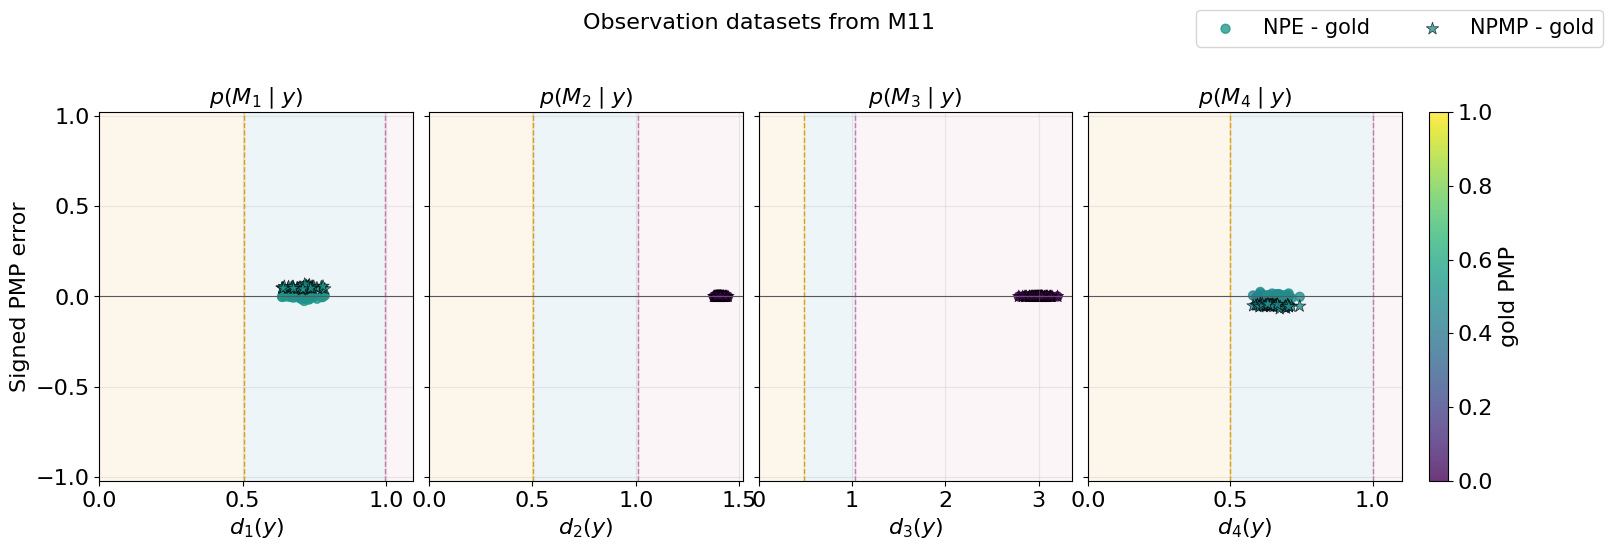

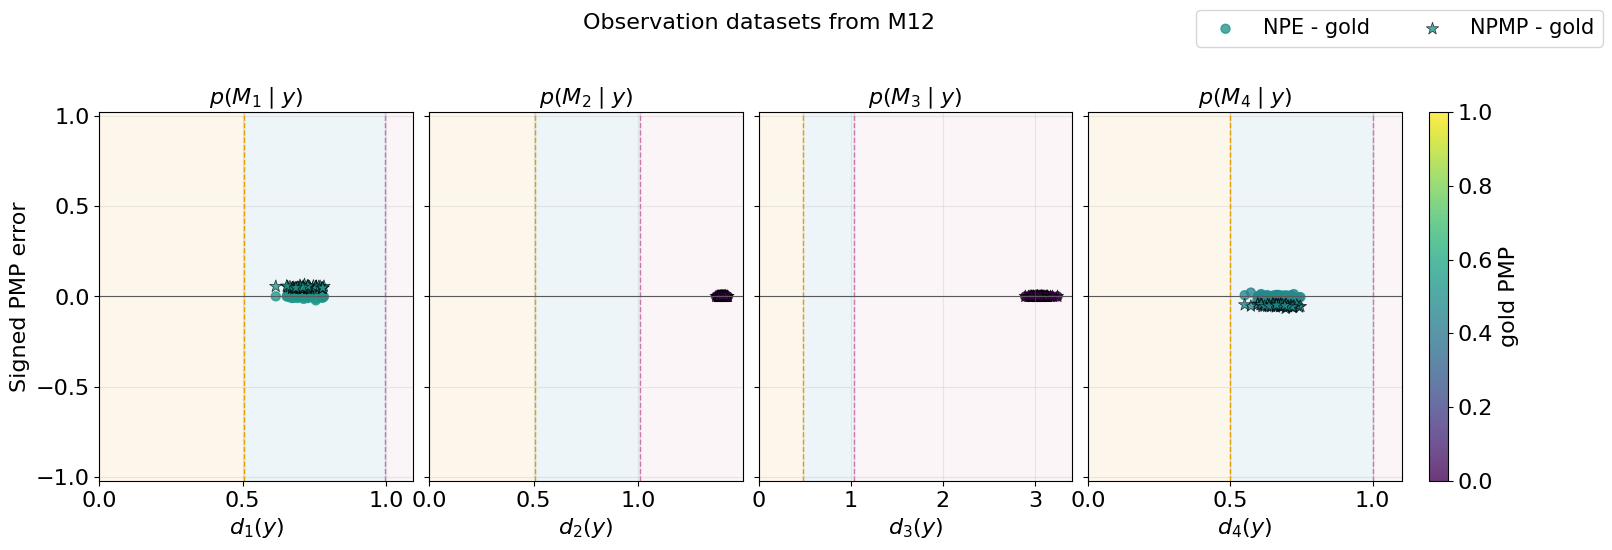

In [14]:
# PMP estimates (NPE and NPMP) vs distance for each source model
for source in sd.SOURCE_MODELS:
    sd.plot_pmp_estimates_vs_distance(pmp_df, source,x="distance",y="signed_error",output_dir=figure_dir)